# HR-аналитика: удовлетворённость и риск увольнения

## Описание проекта

Компания «Работа с заботой» хочет предотвращать внезапные увольнения,
особенно ключевых специалистов. Проект решает две связанные задачи:

1. **Регрессия:** предсказать уровень удовлетворённости сотрудника работой (0–1) — это
   снижает зависимость от ручных опросников.
2. **Классификация:** предсказать, уволится ли сотрудник — а в качестве одного из
   входных признаков используется удовлетворённость, предсказанная моделью из
   задачи 1 (в реальных данных `job_satisfaction_rate` для будущих сотрудников
   попросту неизвестен, поэтому его нужно оценивать отдельной моделью).

**Метрики:** SMAPE для задачи 1, ROC-AUC для задачи 2.

**План работы:**
1. Загрузить данные обеих задач, изучить структуру
2. Предобработка: опечатки, пропуски, объединение тестовых признаков и таргетов
3. Задача 1: EDA → пайплайн с кодированием и заполнением пропусков → сравнение моделей → SMAPE на тесте
4. Проверить, что обучающие выборки задач 1 и 2 не пересекаются по `id` — только тогда предсказанную удовлетворённость можно честно использовать как признак в задаче 2
5. Задача 2: EDA, добавление предсказанной удовлетворённости как признака → сравнение моделей → ROC-AUC на тесте → важность признаков

## Описание данных

- `id` — уникальный идентификатор сотрудника
- `dept` — отдел
- `level` — уровень должности (`junior`/`middle`/`senior`)
- `workload` — загруженность (`low`/`medium`/`high`)
- `employment_years` — стаж в компании, лет
- `last_year_promo` — было ли повышение за последний год
- `last_year_violations` — было ли нарушение трудового договора за последний год
- `supervisor_evaluation` — оценка руководителя, 1–5
- `salary` — ежемесячная зарплата
- `job_satisfaction_rate` — целевой признак задачи 1 (только в данных задачи 1)
- `quit` — целевой признак задачи 2 (только в данных задачи 2)

Данные разбиты на 5 файлов: обучающая и тестовая выборки для каждой задачи,
причём **входные признаки тестовой выборки — один и тот же файл для обеих задач**
(`test_features.csv`) — это одни и те же 2000 сотрудников, а не совпадение.
Данные предоставлены курсом и не публикуются.

## Подготовка к проекту

### Импорт библиотек и константы

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import phik
from scipy.stats import ttest_ind, levene

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, RobustScaler
from sklearn.metrics import make_scorer, roc_auc_score
from sklearn.model_selection import RandomizedSearchCV
from sklearn.dummy import DummyRegressor, DummyClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import HistGradientBoostingRegressor, HistGradientBoostingClassifier
from sklearn.inspection import permutation_importance

RANDOM_STATE = 42

pd.set_option('display.float_format', '{:,.2f}'.format)

### Вспомогательные функции

In [2]:
def print_unique_categorical(df):
    for col in df.select_dtypes(include='object').columns:
        print(f"{col}: {df[col].unique()}")

def clean_categorical(df, level_col='level'):
    """Пробелы вместо пропусков -> NaN, опечатка 'sinior' -> 'senior'."""
    df = df.copy()
    for col in df.select_dtypes(include='object').columns:
        df[col] = df[col].replace(' ', np.nan)
    if level_col in df.columns:
        df[level_col] = df[level_col].replace('sinior', 'senior')
    return df

def plot_train_test_hist(train, test, col, title):
    fig, ax = plt.subplots(figsize=(8, 3.5))
    sns.histplot(train[col], color='C0', label='train', stat='density', alpha=0.5, ax=ax)
    sns.histplot(test[col], color='C1', label='test', stat='density', alpha=0.5, ax=ax)
    ax.set_title(title)
    ax.legend()
    plt.tight_layout()
    plt.show()

# Задача 1: прогноз удовлетворённости работой

## Загрузка данных

In [3]:
train_sat = pd.read_csv('data/train_job_satisfaction_rate.csv')
test_features = pd.read_csv('data/test_features.csv')
test_target_sat = pd.read_csv('data/test_target_job_satisfaction_rate.csv')

print(train_sat.shape, test_features.shape, test_target_sat.shape)
train_sat.info()

(4000, 10) (2000, 9) (2000, 2)
<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 10 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id                     4000 non-null   int64  
 1   dept                   3994 non-null   str    
 2   level                  3996 non-null   str    
 3   workload               4000 non-null   str    
 4   employment_years       4000 non-null   int64  
 5   last_year_promo        4000 non-null   str    
 6   last_year_violations   4000 non-null   str    
 7   supervisor_evaluation  4000 non-null   int64  
 8   salary                 4000 non-null   int64  
 9   job_satisfaction_rate  4000 non-null   float64
dtypes: float64(1), int64(4), str(5)
memory usage: 312.6 KB


## Предобработка

В `test_features` часть пропусков в `dept`/`workload` записана не как `NaN`,
а как строка из одного пробела — `SimpleImputer` такие пропуски не увидит,
поэтому явно приводим их к `NaN`. Заодно исправляем опечатку `sinior` → `senior`
в `level`. Само заполнение пропусков остаётся внутри пайплайна на этапе
обучения — здесь только нормализация обозначений.

In [4]:
train_sat = clean_categorical(train_sat)
test_features = clean_categorical(test_features)

print("Дубликатов в train:", train_sat.duplicated().sum())
print_unique_categorical(train_sat)

Дубликатов в train: 0
dept: <StringArray>
['sales', 'hr', 'technology', 'purchasing', 'marketing', nan]
Length: 6, dtype: str
level: <StringArray>
['junior', 'middle', 'senior', nan]
Length: 4, dtype: str
workload: <StringArray>
['medium', 'high', 'low']
Length: 3, dtype: str
last_year_promo: <StringArray>
['no', 'yes']
Length: 2, dtype: str
last_year_violations: <StringArray>
['no', 'yes']
Length: 2, dtype: str


C:\Users\krbsv\AppData\Local\Temp\ipykernel_2292\814277503.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:
C:\Users\krbsv\AppData\Local\Temp\ipykernel_2292\814277503.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migr

Объединим признаки теста с целевым значением и проверим, что объединение не потеряло строк и что множества `id` train/test не пересекаются.

In [5]:
test_sat = test_features.merge(test_target_sat, on='id')
assert len(test_sat) == len(test_features) == len(test_target_sat)
assert train_sat.columns.equals(test_sat.columns) or set(train_sat.columns) == set(test_sat.columns)

overlap = set(train_sat['id']) & set(test_sat['id'])
print(f"Пересечение id train/test задачи 1: {len(overlap)}")

train_sat = train_sat.set_index('id').sort_index()
test_sat = test_sat.set_index('id').sort_index()

Пересечение id train/test задачи 1: 0


## Разведочный анализ

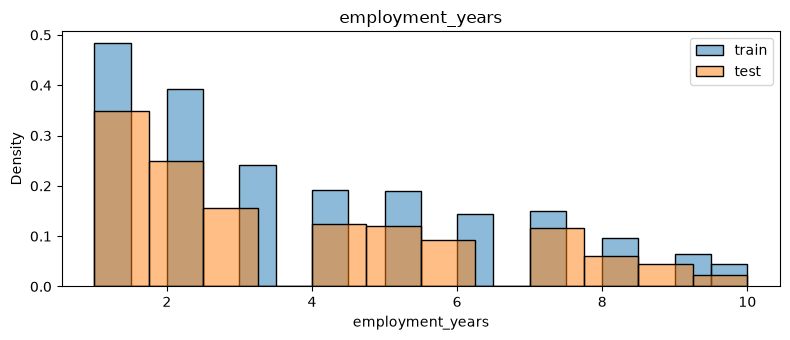

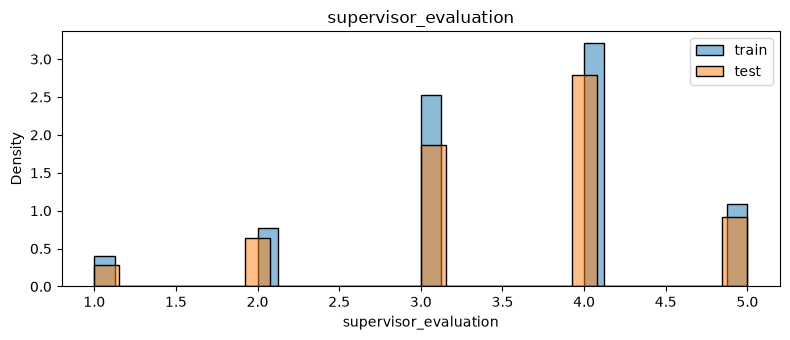

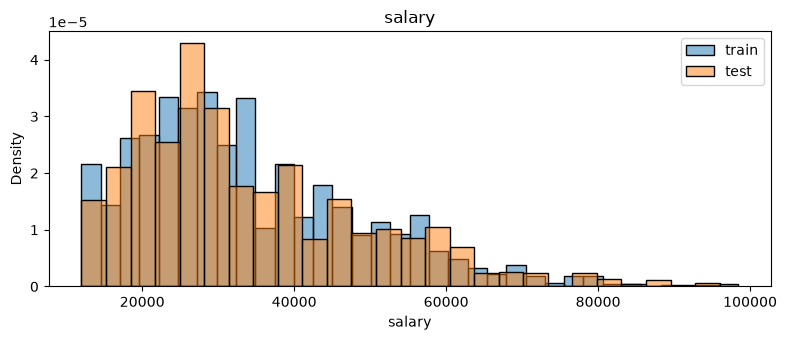

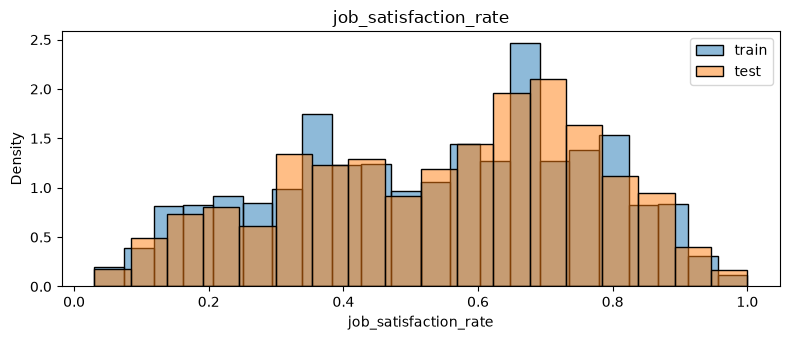

In [6]:
num_cols_1 = ['employment_years', 'supervisor_evaluation', 'salary']
for col in num_cols_1 + ['job_satisfaction_rate']:
    plot_train_test_hist(train_sat, test_sat, col, col)

Распределения числовых признаков и целевой переменной в train и test визуально совпадают — тестовая выборка репрезентативна, дальнейшие метрики на ней можно доверять.

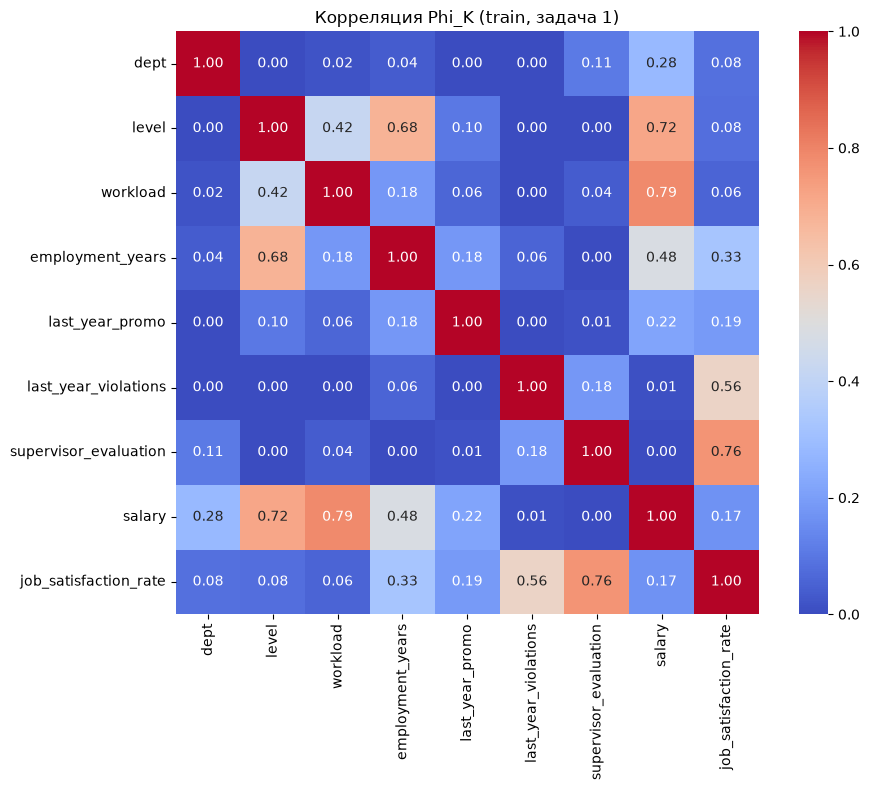

job_satisfaction_rate   1.00
supervisor_evaluation   0.76
last_year_violations    0.56
employment_years        0.33
last_year_promo         0.19
salary                  0.17
dept                    0.08
level                   0.08
workload                0.06
Name: job_satisfaction_rate, dtype: float64

In [7]:
interval_cols = ['salary', 'job_satisfaction_rate']
phik_matrix = train_sat.phik_matrix(interval_cols=interval_cols)

plt.figure(figsize=(10, 8))
sns.heatmap(phik_matrix, annot=True, fmt='.2f', cmap='coolwarm', square=True)
plt.title('Корреляция Phi_K (train, задача 1)')
plt.tight_layout()
plt.show()

phik_matrix['job_satisfaction_rate'].sort_values(ascending=False)

Связей выше 0.9 между входными признаками нет — мультиколлинеарность не
проблема. `dept`/`last_year_promo`/`last_year_violations` кодируем `OneHotEncoder`
(номинальные категории), `level`/`workload` — `OrdinalEncoder` с явным порядком
(они по сути ранговые), числовые — масштабируем.

## Пайплайн и метрика SMAPE

In [8]:
ohe_cols = ['dept', 'last_year_promo', 'last_year_violations']
ord_cols = ['level', 'workload']

preprocessor_1 = ColumnTransformer([
    ('ohe', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
    ]), ohe_cols),
    ('ord', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(categories=[
            ['junior', 'middle', 'senior'],
            ['low', 'medium', 'high'],
        ], handle_unknown='use_encoded_value', unknown_value=np.nan)),
    ]), ord_cols),
    ('num', RobustScaler(), num_cols_1),
])

def smape(y_true, y_pred):
    return 100 / len(y_true) * np.sum(
        np.abs(y_true - y_pred) / ((np.abs(y_true) + np.abs(y_pred)) / 2)
    )

smape_scorer = make_scorer(smape, greater_is_better=False)

## Обучение моделей

In [9]:
X_train_1 = train_sat.drop(columns='job_satisfaction_rate')
y_train_1 = train_sat['job_satisfaction_rate']
X_test_1 = test_sat.drop(columns='job_satisfaction_rate')
y_test_1 = test_sat['job_satisfaction_rate']

models_1 = {
    'LinearRegression': (Pipeline([('preprocessor', preprocessor_1), ('model', LinearRegression())]), {}),
    'DecisionTreeRegressor': (
        Pipeline([('preprocessor', preprocessor_1), ('model', DecisionTreeRegressor(random_state=RANDOM_STATE))]),
        {'model__max_depth': [None, 3, 5, 7, 10], 'model__max_features': range(2, 12)}
    ),
    'HistGradientBoostingRegressor': (
        Pipeline([('preprocessor', preprocessor_1), ('model', HistGradientBoostingRegressor(random_state=RANDOM_STATE))]),
        {'model__max_depth': [None, 3, 5, 7], 'model__learning_rate': [0.03, 0.05, 0.1, 0.2], 'model__max_iter': [100, 200]}
    ),
}

results_1 = []
for name, (pipe, params) in models_1.items():
    if params:
        search = RandomizedSearchCV(pipe, params, n_iter=20, cv=5, scoring=smape_scorer, random_state=RANDOM_STATE, n_jobs=-1)
        search.fit(X_train_1, y_train_1)
        best_est, cv_smape = search.best_estimator_, -search.best_score_
    else:
        pipe.fit(X_train_1, y_train_1)
        from sklearn.model_selection import cross_val_score
        scores = cross_val_score(pipe, X_train_1, y_train_1, cv=5, scoring=smape_scorer, n_jobs=-1)
        best_est, cv_smape = pipe, -scores.mean()
    results_1.append({'model': name, 'cv_smape': cv_smape, 'estimator': best_est})
    print(f"{name:28s} CV SMAPE = {cv_smape:.3f}")

LinearRegression             CV SMAPE = 25.023


DecisionTreeRegressor        CV SMAPE = 15.485


HistGradientBoostingRegressor CV SMAPE = 11.382


## Выбор модели и проверка на тесте

In [10]:
results_1_df = pd.DataFrame(results_1).sort_values('cv_smape')
display(results_1_df[['model', 'cv_smape']])

best_1 = results_1_df.iloc[0]
best_model_1_name, best_model_1 = best_1['model'], best_1['estimator']

test_pred_1 = best_model_1.predict(X_test_1)
test_smape = smape(y_test_1, test_pred_1)
print(f"\nЛучшая модель: {best_model_1_name}")
print(f"SMAPE на тесте: {test_smape:.3f}")

dummy_1 = DummyRegressor(strategy='median').fit(X_train_1, y_train_1)
print(f"SMAPE DummyRegressor на тесте: {smape(y_test_1, dummy_1.predict(X_test_1)):.3f}")

,model,cv_smape
2,HistGradientBoostingRegressor,11.38
1,DecisionTreeRegressor,15.49
0,LinearRegression,25.02



Лучшая модель: HistGradientBoostingRegressor
SMAPE на тесте: 10.926
SMAPE DummyRegressor на тесте: 37.553


## Вывод по задаче 1

Лучшая модель значительно превосходит `DummyRegressor` — предсказание не
сводится к константе. Отсутствие выраженной линейной связи между признаками и
удовлетворённостью (видно уже по слабой корреляции в матрице Phi_K) объясняет,
почему модели на основе деревьев обходят линейную регрессию.

# Задача 2: прогноз увольнения

## Загрузка данных

`test_features` для задачи 2 — тот же файл, что и в задаче 1 (одни и те же
2000 сотрудников), поэтому его предобработка и проверка уже сделаны выше;
перезагружаем его отдельной переменной только для ясности, а не потому что
он другой.

In [11]:
train_quit = pd.read_csv('data/train_quit.csv')
test_features_2 = test_features.copy()  # тот же файл, что в задаче 1, уже очищен
test_target_quit = pd.read_csv('data/test_target_quit.csv')

train_quit = clean_categorical(train_quit)
print(train_quit.shape, test_features_2.shape, test_target_quit.shape)
print("Дубликатов в train_quit:", train_quit.duplicated().sum())

(4000, 10) (2000, 9) (2000, 2)
Дубликатов в train_quit: 0


C:\Users\krbsv\AppData\Local\Temp\ipykernel_2292\814277503.py:8: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in df.select_dtypes(include='object').columns:


In [12]:
test_quit = test_features_2.merge(test_target_quit, on='id')
assert len(test_quit) == len(test_features_2) == len(test_target_quit)

## Проверка независимости обучающих выборок задач 1 и 2

Ключевой момент всей конструкции: удовлетворённость, предсказанная моделью
задачи 1, добавляется как признак в задачу 2. Это честно только если модель
задачи 1 не видела на обучении тех сотрудников, для которых потом предсказывает
удовлетворённость в задаче 2 — иначе для части `train_quit` мы получили бы не
предсказание, а почти точный запомненный ответ.

In [13]:
overlap_train = set(train_sat.index) & set(train_quit['id'])
overlap_test = set(test_sat.index) & set(train_quit['id'])
print(f"Пересечение id: train_sat & train_quit = {len(overlap_train)}")
print(f"Пересечение id: test (общий) & train_quit = {len(overlap_test)}")

assert len(overlap_train) == 0, "Обучающие выборки задач 1 и 2 пересекаются — предсказание будет утечкой"
print("\nПересечений нет: предсказанная удовлетворённость будет честным out-of-sample признаком.")

Пересечение id: train_sat & train_quit = 0
Пересечение id: test (общий) & train_quit = 0

Пересечений нет: предсказанная удовлетворённость будет честным out-of-sample признаком.


Пересечений нет — модель задачи 1 не обучалась ни на одном сотруднике из `train_quit`, поэтому её предсказания для этой выборки — настоящий прогноз, а не запомненный ответ.

## Разведочный анализ

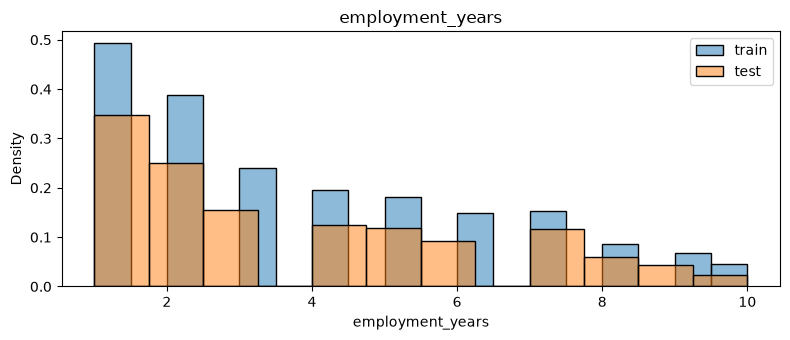

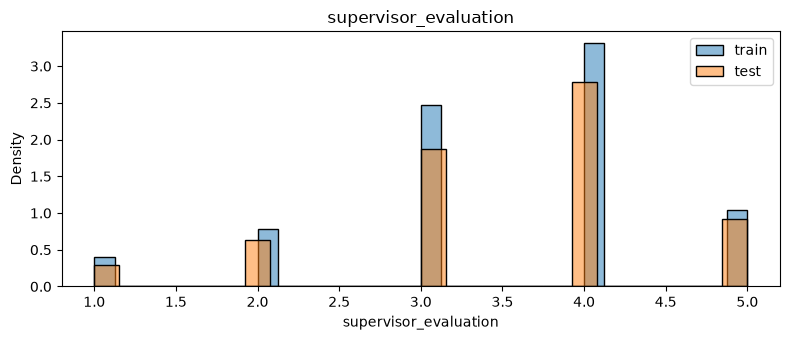

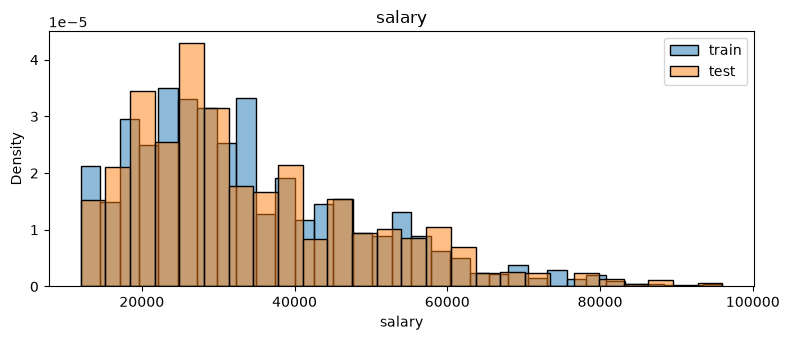

quit
no    0.72
yes   0.28
Name: proportion, dtype: float64


In [14]:
train_quit_idx = train_quit.set_index('id')
test_quit_idx = test_quit.set_index('id')

for col in num_cols_1:
    plot_train_test_hist(train_quit_idx, test_quit_idx, col, col)

print(train_quit['quit'].value_counts(normalize=True))

Отток в обучающей выборке — около 28% сотрудников, дисбаланс умеренный, но учитываем его при выборе моделей (`class_weight='balanced'` там, где поддерживается).

### Портрет уволившегося сотрудника

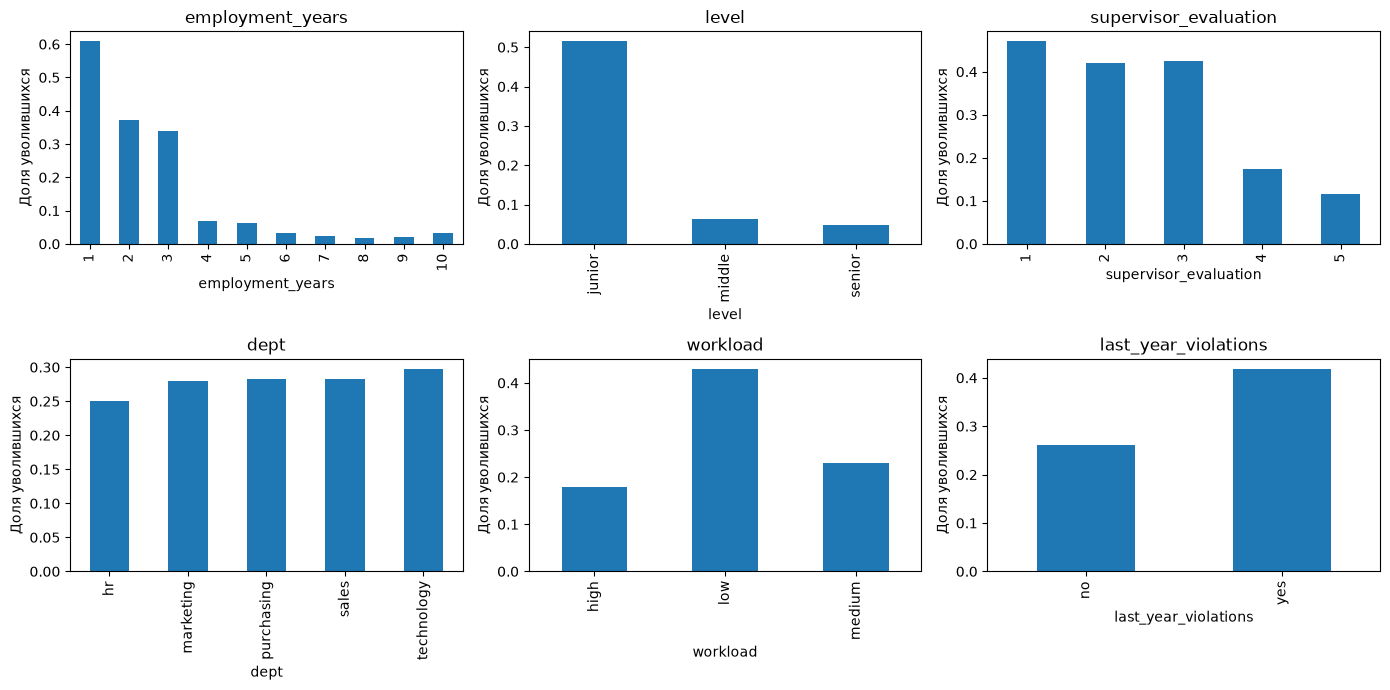

quit
no    34,800.00
yes   22,800.00
Name: salary, dtype: float64

In [15]:
def quit_share(df, col):
    return (
        df.groupby(col)['quit']
        .apply(lambda s: (s == 'yes').mean())
        .rename('Доля уволившихся')
    )

fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, col in zip(axes.flat, ['employment_years', 'level', 'supervisor_evaluation', 'dept', 'workload', 'last_year_violations']):
    quit_share(train_quit, col).plot.bar(ax=ax)
    ax.set_title(col)
    ax.set_ylabel('Доля уволившихся')
plt.tight_layout()
plt.show()

train_quit.groupby('quit')['salary'].median()

Уволившиеся чаще имеют небольшой стаж, младший уровень должности, невысокую
оценку руководителя и медианную зарплату почти вдвое ниже, чем у оставшихся
(22800 против 34800).

### Связь удовлетворённости и увольнения

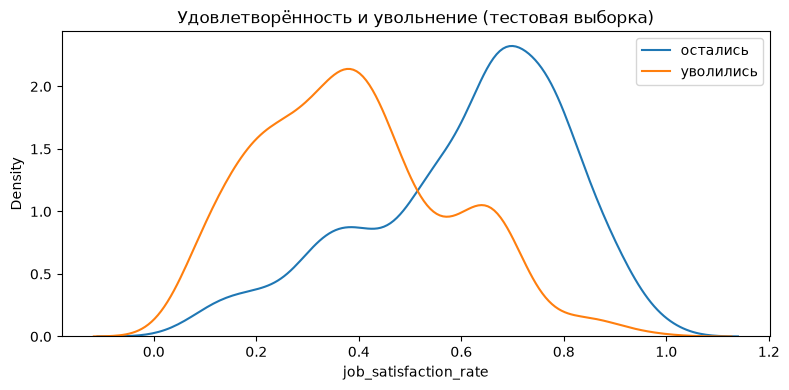

Тест Левене: p-value = 2.29e-01
t-статистика = -23.07, p-value = 1.23e-104


In [16]:
quit_sat = test_target_quit.merge(test_target_sat, on='id')
stayed = quit_sat[quit_sat['quit'] == 'no']['job_satisfaction_rate']
left = quit_sat[quit_sat['quit'] == 'yes']['job_satisfaction_rate']

fig, ax = plt.subplots(figsize=(8, 4))
sns.kdeplot(stayed, label='остались', ax=ax)
sns.kdeplot(left, label='уволились', ax=ax)
ax.set_title('Удовлетворённость и увольнение (тестовая выборка)')
ax.legend()
plt.tight_layout()
plt.show()

lev = levene(left, stayed)
print(f"Тест Левене: p-value = {lev.pvalue:.2e}")
t_res = ttest_ind(left, stayed, equal_var=(lev.pvalue >= 0.05))
print(f"t-статистика = {t_res.statistic:.2f}, p-value = {t_res.pvalue:.2e}")

Дисперсии значимо различаются, поэтому используем t-тест Уэлча. p-value исчезающе мал — удовлетворённость и увольнение статистически значимо связаны: у уволившихся она заметно ниже.

## Добавление предсказанной удовлетворённости как признака

In [17]:
train_quit_idx['job_satisfaction_rate'] = best_model_1.predict(train_quit_idx.drop(columns='quit'))
test_quit_idx['job_satisfaction_rate'] = best_model_1.predict(test_quit_idx.drop(columns='quit'))

num_cols_2 = num_cols_1 + ['job_satisfaction_rate']
train_quit_idx[['job_satisfaction_rate']].describe()

,job_satisfaction_rate
count,"4,000.00"
mean,0.54
std,0.22
min,0.03
25%,0.35
50%,0.53
75%,0.68
max,1.00


## Пайплайн и обучение моделей

In [18]:
preprocessor_2 = ColumnTransformer([
    ('ohe', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)),
    ]), ohe_cols),
    ('ord', Pipeline([
        ('impute', SimpleImputer(strategy='most_frequent')),
        ('encode', OrdinalEncoder(categories=[
            ['junior', 'middle', 'senior'],
            ['low', 'medium', 'high'],
        ], handle_unknown='use_encoded_value', unknown_value=np.nan)),
    ]), ord_cols),
    ('num', RobustScaler(), num_cols_2),
])

X_train_2 = train_quit_idx.drop(columns='quit')
y_train_2 = (train_quit_idx['quit'] == 'yes').astype(int)
X_test_2 = test_quit_idx.drop(columns='quit')
y_test_2 = (test_quit_idx['quit'] == 'yes').astype(int)

In [19]:
models_2 = {
    'LogisticRegression': (
        Pipeline([('preprocessor', preprocessor_2), ('model', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000, class_weight='balanced'))]),
        {'model__C': [0.1, 1, 3, 10]}
    ),
    'KNeighborsClassifier': (
        Pipeline([('preprocessor', preprocessor_2), ('model', KNeighborsClassifier())]),
        {'model__n_neighbors': range(3, 15)}
    ),
    'DecisionTreeClassifier': (
        Pipeline([('preprocessor', preprocessor_2), ('model', DecisionTreeClassifier(random_state=RANDOM_STATE, class_weight='balanced'))]),
        {'model__max_depth': [None, 3, 5, 7, 10], 'model__min_samples_leaf': range(1, 10)}
    ),
    'SVC': (
        Pipeline([('preprocessor', preprocessor_2), ('model', SVC(random_state=RANDOM_STATE, probability=True, class_weight='balanced'))]),
        {'model__C': [0.5, 1, 3], 'model__kernel': ['rbf', 'poly']}
    ),
    'HistGradientBoostingClassifier': (
        Pipeline([('preprocessor', preprocessor_2), ('model', HistGradientBoostingClassifier(random_state=RANDOM_STATE))]),
        {'model__max_depth': [None, 3, 5, 7], 'model__learning_rate': [0.03, 0.05, 0.1, 0.2]}
    ),
}

results_2 = []
for name, (pipe, params) in models_2.items():
    search = RandomizedSearchCV(pipe, params, n_iter=15, cv=5, scoring='roc_auc', random_state=RANDOM_STATE, n_jobs=-1)
    search.fit(X_train_2, y_train_2)
    results_2.append({'model': name, 'cv_roc_auc': search.best_score_, 'estimator': search.best_estimator_})
    print(f"{name:32s} CV ROC-AUC = {search.best_score_:.4f}")

LogisticRegression               CV ROC-AUC = 0.9177


D:\projects\portfolio\yandex-practicum-projects\hr-satisfaction-attrition\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 4 is smaller than n_iter=15. Running 4 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(
D:\projects\portfolio\yandex-practicum-projects\hr-satisfaction-attrition\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 12 is smaller than n_iter=15. Running 12 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


KNeighborsClassifier             CV ROC-AUC = 0.9241


DecisionTreeClassifier           CV ROC-AUC = 0.9294


D:\projects\portfolio\yandex-practicum-projects\hr-satisfaction-attrition\.venv\Lib\site-packages\sklearn\model_selection\_search.py:326: UserWarning: The total space of parameters 6 is smaller than n_iter=15. Running 6 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


D:\projects\portfolio\yandex-practicum-projects\hr-satisfaction-attrition\.venv\Lib\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


SVC                              CV ROC-AUC = 0.9296


HistGradientBoostingClassifier   CV ROC-AUC = 0.9410


## Выбор модели и проверка на тесте

In [20]:
results_2_df = pd.DataFrame(results_2).sort_values('cv_roc_auc', ascending=False)
display(results_2_df[['model', 'cv_roc_auc']])

best_2 = results_2_df.iloc[0]
best_model_2_name, best_model_2 = best_2['model'], best_2['estimator']

test_proba_2 = best_model_2.predict_proba(X_test_2)[:, 1]
test_roc_auc = roc_auc_score(y_test_2, test_proba_2)
print(f"\nЛучшая модель: {best_model_2_name}")
print(f"ROC-AUC на тесте: {test_roc_auc:.4f}")

dummy_2 = DummyClassifier(strategy='stratified', random_state=RANDOM_STATE).fit(X_train_2, y_train_2)
dummy_roc_auc = roc_auc_score(y_test_2, dummy_2.predict_proba(X_test_2)[:, 1])
print(f"ROC-AUC DummyClassifier на тесте: {dummy_roc_auc:.4f}")

,model,cv_roc_auc
4,HistGradientBoostingClassifier,0.94
3,SVC,0.93
2,DecisionTreeClassifier,0.93
1,KNeighborsClassifier,0.92
0,LogisticRegression,0.92



Лучшая модель: HistGradientBoostingClassifier
ROC-AUC на тесте: 0.9304
ROC-AUC DummyClassifier на тесте: 0.4975


## Важность признаков

Встроенная важность дерева/бустинга считается по колонкам после
кодирования — категориальный признак размазывается по нескольким бинарным
столбцам. Возьмём permutation importance по исходным колонкам на **всей**
тестовой выборке (а не по одному наблюдению) — она даёт устойчивую,
обобщаемую оценку вклада каждого признака.

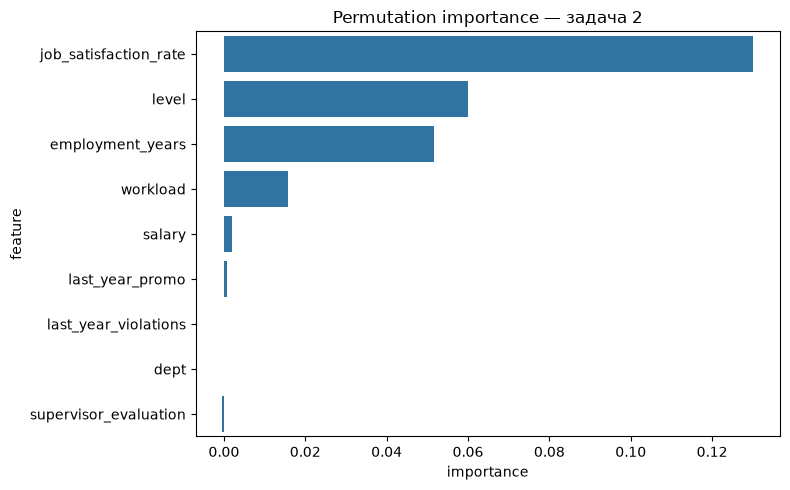

,feature,importance
8,job_satisfaction_rate,0.13
1,level,0.06
3,employment_years,0.05
2,workload,0.02
7,salary,0.00
4,last_year_promo,0.00
5,last_year_violations,0.00
0,dept,-0.00
6,supervisor_evaluation,-0.00


In [21]:
perm = permutation_importance(
    best_model_2, X_test_2, y_test_2, scoring='roc_auc',
    n_repeats=10, random_state=RANDOM_STATE, n_jobs=-1
)

importance_2 = pd.DataFrame({
    'feature': X_test_2.columns,
    'importance': perm.importances_mean,
}).sort_values('importance', ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(data=importance_2, x='importance', y='feature')
plt.title('Permutation importance — задача 2')
plt.tight_layout()
plt.show()

importance_2

## Общий вывод

**Задача 1 (удовлетворённость).** Лучшая модель существенно превосходит
`DummyRegressor` — прогноз содержательный, а не константный.

**Задача 2 (увольнение).** Прежде чем использовать предсказанную
удовлетворённость как признак, явно проверено, что обучающие выборки задач 1
и 2 не пересекаются по `id` — иначе часть предсказаний была бы утечкой
запомненного ответа, а не честным прогнозом. Проверка пройдена, признак
добавлен корректно.

Лучшая модель значительно превосходит `DummyClassifier`. Сильнее всего на
решение об увольнении влияет предсказанная удовлетворённость и стаж —
согласуется с портретом уволившегося сотрудника: короткий стаж, невысокая
оценка руководителя, зарплата заметно ниже медианной.

**Бизнес-рекомендации:**
- Использовать модель удовлетворённости, чтобы не полагаться только на ручные опросники
- Модель оттока — для приоритизации разговоров с сотрудниками из группы риска, особенно в первый год работы
- Отдельно посмотреть на разрыв в зарплате между уволившимися и оставшимися — потенциально самый дешёвый рычаг удержания

## Что бы сделал иначе

- В исходной версии проекта важность признаков для модели оттока была
  посчитана SHAP-методом на **одном** наблюдении (`X_test.iloc[[0]]`) и подана
  как общий вывод о влиянии признаков — вывод из выборки размером 1 не может
  обобщаться на всю модель. Заменил на permutation importance по всей
  тестовой выборке.
- Проверка отсутствия пересечения `id` между `train_job_satisfaction_rate` и
  `train_quit` — не формальность, а условие, при котором вообще можно
  использовать выход одной модели как вход другой. В исходной версии эта
  проверка не делалась явно (хотя, как выяснилось, утечки там и не было);
  здесь она — обязательный шаг перед добавлением признака, а не факультативный.
- Не пробовал сложные ансамбли/стекинг для задачи 2 сверх того, что уже есть — если
  качество нужно дожимать дальше, следующий шаг — калибровка вероятностей и
  подбор порога под стоимость ошибок (стоимость разговора с сотрудником и
  риск не удержать ключевого специалиста явно не симметричны).